In [ ]:
import sys
import warnings

sys.path.append("/kaggle/input/myscripts")
warnings.filterwarnings("ignore")


import pandas as pd
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

from matplotlib import pyplot as plt
%matplotlib inline
%config InlineBackend.figure_format = "retina"
plt.rcParams["figure.figsize"] = (8, 5)
plt.rcParams["font.size"] = 12


from seq_models import SeqDataset, collate_fn, LSTMClassifier, TransformerClassifier, train, evaluate
from metric_utils import bootstrap_metrics

## Датасет [Diabets](https://www.kaggle.com/datasets/uciml/pima-indians-diabetes-database)

In [6]:
import kagglehub

path = kagglehub.dataset_download("uciml/pima-indians-diabetes-database") + "/diabetes.csv"

df = pd.read_csv(path)
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [7]:
X = df.drop(columns=["Outcome"])
y = df["Outcome"]
le = LabelEncoder()
y = le.fit_transform(y)
labels = y.tolist()

In [8]:
categorical_features = []
numerical_features = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age"]
scaler = StandardScaler()
X_numerical = scaler.fit_transform(X[numerical_features])

X_combined = X_numerical

X_seqs = [row.reshape(len(row), 1) for row in X_combined]
train_data, test_data, train_labels, test_labels = train_test_split(X_seqs, labels, test_size=0.2, random_state=0, stratify=y, shuffle=True)
test_data, valid_data, test_labels, valid_labels = train_test_split(test_data, test_labels, test_size=0.5, random_state=0, stratify=test_labels, shuffle=True)

In [9]:
train_dataset = SeqDataset(train_data, train_labels)
test_dataset  = SeqDataset(test_data, test_labels)
valid_dataset = SeqDataset(valid_data, valid_labels)

batch_size = 64
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, collate_fn=collate_fn)
test_loader  = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False, collate_fn=collate_fn)

In [10]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

cuda


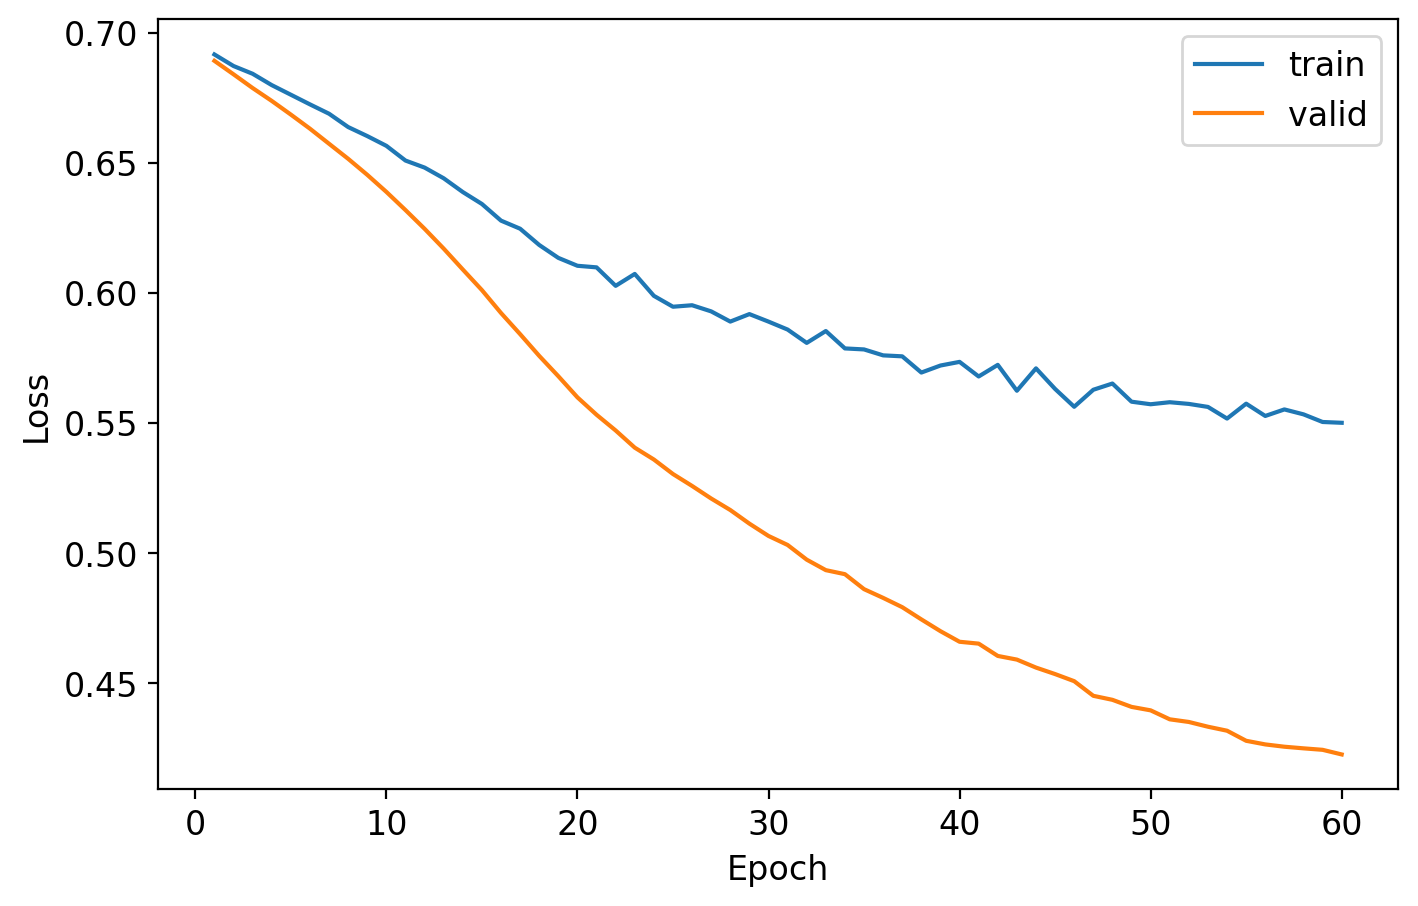

Epoch 60: train loss = 0.5500; valid loss = 0.4226


In [33]:
model_lstm = LSTMClassifier().to(device)
optimizer = optim.Adam(model_lstm.parameters(), lr=1e-4)
criterion = nn.CrossEntropyLoss()

train(model_lstm, optimizer, 60, train_loader, valid_loader, criterion, device, scheduler=None)

In [35]:
y_true, y_prob, y_pred = evaluate(model_lstm, test_loader, device)
metrics_lstm = bootstrap_metrics(y_true, y_pred, y_prob)

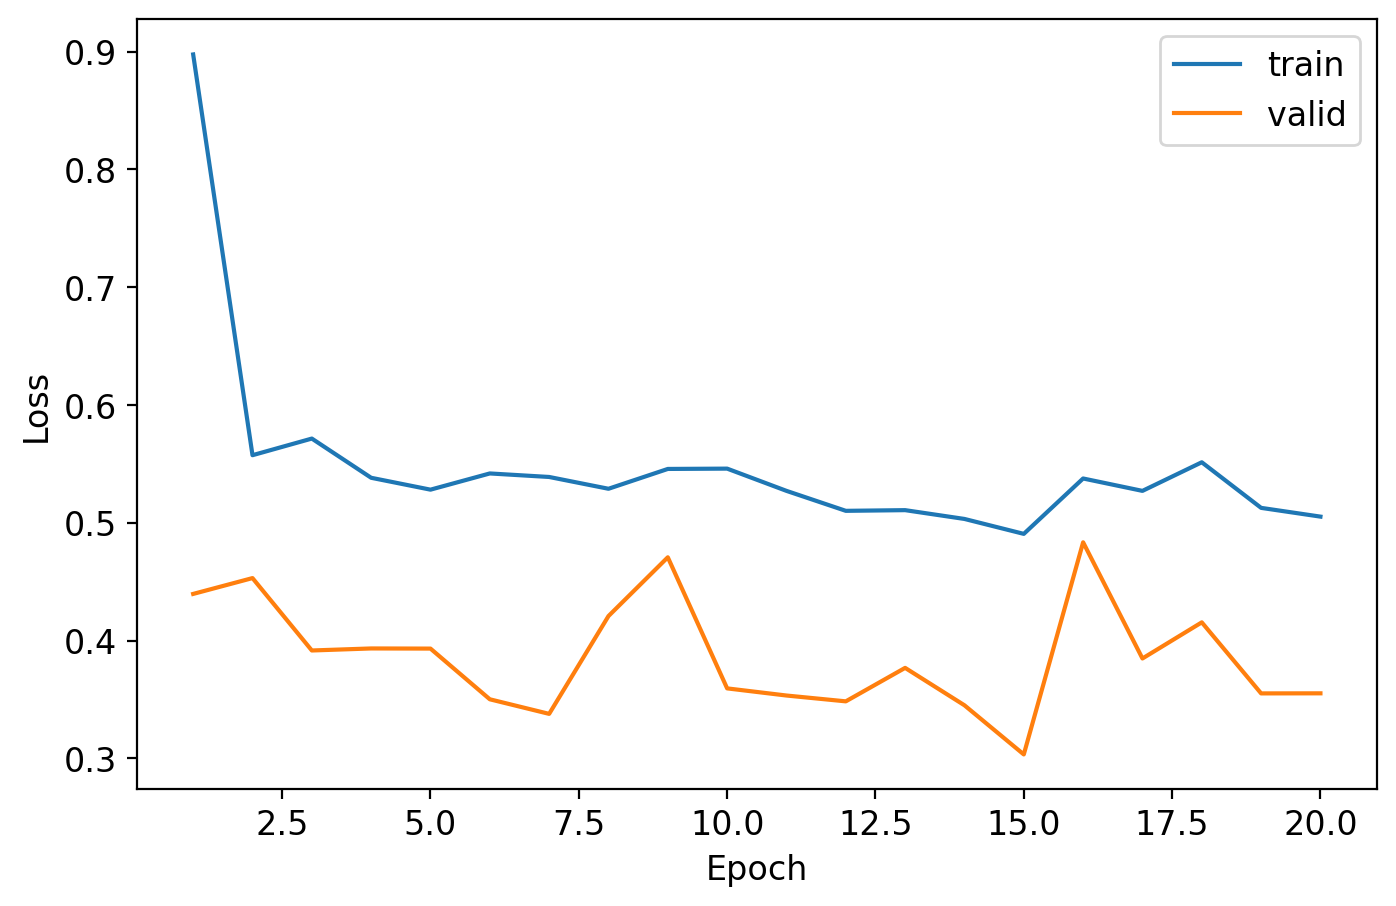

Epoch 20: train loss = 0.5052; valid loss = 0.3552


In [64]:
model_enc = TransformerClassifier(maxlen=len(train_data[0])).to(device)
optimizer = optim.Adam(model_enc.parameters(), lr=1e-3)
criterion = nn.CrossEntropyLoss()

train(model_enc, optimizer, 20, train_loader, valid_loader, criterion, device, scheduler=None)

In [65]:
y_true, y_prob, y_pred = evaluate(model_enc, test_loader, device)
metrics_enc = bootstrap_metrics(y_true, y_pred, y_prob)

In [66]:
res = pd.DataFrame([{"model": "LSTM"} | metrics_lstm, {"model": "Transformer"} | metrics_enc])
res

,model,ROC-AUC,F1,Accuracy,Precision,Recall
0,LSTM,0.7115±0.0671,0.4550±0.0999,0.7285±0.0499,0.7461±0.1250,0.3341±0.0918
1,Transformer,0.7811±0.0552,0.6097±0.0809,0.7403±0.0500,0.6366±0.0974,0.5934±0.0947
